# D2: Overfit 1 Trajectory, No Quaternions

**Sanity check:** Can the diffusion model memorize a single rollout (60 steps, ~26 chunks)?

If the model can't drive chunk L2 → 0 on 26 chunks, there's a bug in the model,
loss function, or conditioning mechanism. If it can memorize, the model works and
the problem is generalization/data diversity.

**Config (designed for fast memorization):**

| Parameter | D1 (8.5k no-quat) | This notebook (D2) |
|-----------|-------------------|--------------------|
| Rollouts | 50 | **1** |
| Chunks | ~1300 | **~26** |
| State dim | 11 | 11 |
| LR | 3e-4 + cosine | **1e-3, no scheduler** |
| Epochs | 500 | **2000** |
| Steps/epoch | ~17 | **~1** (26 chunks / batch 64 → 1 batch, drop_last disabled) |
| Total steps | 8,500 | **~2000** |
| Expected time | ~15 min | **< 5 min** |

**Success criteria:** Chunk L2 < 0.1 (near-perfect memorization).

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import h5py
import torch

REPO_ROOT = Path("../../").resolve()
sys.path.insert(0, str(REPO_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Repo root: {REPO_ROOT}")

# --- Common paths ---
POLICY_DIR = REPO_ROOT / "third_party" / "robomimic" / "diffusion_policy_trained_models" / "test"
policy_train_dirs = sorted([d for d in POLICY_DIR.glob("*") if d.is_dir()])
assert len(policy_train_dirs) > 0, "No trained policies found."
policy_train_dir = policy_train_dirs[-1]
print(f"Using policy from: {policy_train_dir}")

# --- Hyperparams (tuned for memorization) ---
N_ROLLOUTS = 1        # Single trajectory
EPOCHS = 2000         # Many passes over ~26 chunks
HORIZON = 60
gamma = 1.0
BATCH_SIZE = 64       # Larger than dataset → sees all chunks every step
NUM_TRAJS = 1         # Generate 1 synthetic trajectory to compare
LR = 1e-3             # High LR for fast memorization (no scheduler)

CHECKPOINT_EPOCHS = [100, 500, 1000, 2000]

# --- Quaternion removal config (same as D1) ---
KEEP_INDICES = [0, 1, 2, 7, 8, 9, 10, 11, 12, 17, 18]
REDUCED_STATE_DIM = len(KEEP_INDICES)  # 11

DIM_LABELS = [
    "obj_px", "obj_py", "obj_pz",
    "g2c_x", "g2c_y", "g2c_z",
    "eef_px", "eef_py", "eef_pz",
    "grip_0", "grip_1",
]

CUBE_Z_IDX = 2
EEF_Z_IDX = 8
CUBE_X_IDX = 0
EEF_X_IDX = 6
SUCCESS_THRESHOLD = 0.84

print(f"D2 overfit sanity check: {N_ROLLOUTS} rollout, {EPOCHS} epochs, LR={LR}, no scheduler")
print(f"State dim: {REDUCED_STATE_DIM} (no quaternions)")

Device: cuda
Repo root: /home1/reishuen/latent_sope
Using policy from: /home1/reishuen/latent_sope/third_party/robomimic/diffusion_policy_trained_models/test/20260309132349
D2 overfit sanity check: 1 rollout, 2000 epochs, LR=0.001, no scheduler
State dim: 11 (no quaternions)


## Step 0: Oracle (cached, unchanged)

In [2]:
from src.latent_sope.eval.oracle import load_oracle_result

oracle_path = policy_train_dir / "oracle_50.json"
assert oracle_path.exists()

oracle_result = load_oracle_result(oracle_path)
oracle_value = oracle_result.mean_return
print(f"Oracle V^pi = {oracle_value:.3f} (std={np.std(oracle_result.returns):.3f}, K={oracle_result.num_rollouts})")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Oracle V^pi = 0.540 (std=0.498, K=50)


## Step 1: Load 1 Rollout & Strip Quaternions

In [3]:
from src.latent_sope.robomimic_interface.rollout import load_rollout_latents

# Use the filtered no-quat rollouts if they exist, otherwise create from originals
filtered_dir = policy_train_dir / "rollout_latents_50_no_quat"
original_dir = policy_train_dir / "rollout_latents_50"

if filtered_dir.exists() and len(list(filtered_dir.glob("*.h5"))) >= 1:
    # Reuse from D1 run
    rollout_paths = [sorted(filtered_dir.glob("*.h5"))[0]]
    print(f"Using pre-filtered rollout: {rollout_paths[0].name}")
else:
    # Create filtered version of first rollout
    filtered_dir.mkdir(exist_ok=True)
    src_path = sorted(original_dir.glob("*.h5"))[0]
    dst_path = filtered_dir / src_path.name

    with h5py.File(str(src_path), "r") as f_in:
        latents_full = np.asarray(f_in["latents"], dtype=np.float32)
        actions = np.asarray(f_in["actions"], dtype=np.float32)
        rewards = np.asarray(f_in["rewards"], dtype=np.float32)
        dones = np.asarray(f_in["dones"])
        attrs = dict(f_in.attrs)

    if latents_full.ndim == 3:
        latents_reduced = latents_full[:, :, KEEP_INDICES]
    else:
        latents_reduced = latents_full[:, KEEP_INDICES]

    with h5py.File(str(dst_path), "w") as f_out:
        f_out.create_dataset("latents", data=latents_reduced, compression="gzip")
        f_out.create_dataset("actions", data=actions, compression="gzip")
        f_out.create_dataset("rewards", data=rewards, compression="gzip")
        f_out.create_dataset("dones", data=dones, compression="gzip")
        for k, v in attrs.items():
            f_out.attrs[k] = v

    rollout_paths = [dst_path]
    print(f"Created filtered rollout: {dst_path.name}")

# Verify
sample_traj = load_rollout_latents(rollout_paths[0])
latents_dim = sample_traj.latents.shape[-1]
action_dim = sample_traj.actions.shape[-1]
print(f"Latent shape: {sample_traj.latents.shape}, Action shape: {sample_traj.actions.shape}")
print(f"Latent dim: {latents_dim}, Action dim: {action_dim}")
print(f"Trajectory length: {sample_traj.horizon} steps")
print(f"Total reward: {sample_traj.total_reward}, Success: {sample_traj.success}")

Using pre-filtered rollout: rollout_000.h5
Latent shape: (41, 2, 11), Action shape: (41, 7)
Latent dim: 11, Action dim: 7
Trajectory length: 41 steps
Total reward: 1.0, Success: True


## Step 2: Chunk the Single Trajectory

In [4]:
from src.latent_sope.robomimic_interface.dataset import (
    RolloutChunkDatasetConfig,
    make_rollout_chunk_dataloader,
)

dataset_config = RolloutChunkDatasetConfig(
    chunk_size=8,
    stride=2,
    frame_stack=2,
    source="latents",
    latents_dim=latents_dim,
    action_dim=action_dim,
    normalize=True,
    return_metadata=True,
)

# drop_last=False so we don't lose the only batch!
dataloader, norm_stats = make_rollout_chunk_dataloader(
    paths=rollout_paths,
    config=dataset_config,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

n_batches = len(dataloader)
n_chunks = len(dataloader.dataset)
print(f"Dataset: {n_chunks} chunks from 1 trajectory")
print(f"DataLoader: {n_batches} batch(es) of up to {BATCH_SIZE}")
print(f"Total gradient steps over {EPOCHS} epochs: {n_batches * EPOCHS}")
print(f"Each chunk seen ~{EPOCHS * BATCH_SIZE / max(n_chunks, 1):.0f} times")
print(f"Normalization stats: mean shape={norm_stats.mean.shape}")

Dataset: 17 chunks from 1 trajectory
DataLoader: 1 batch(es) of up to 64
Total gradient steps over 2000 epochs: 2000
Each chunk seen ~7529 times
Normalization stats: mean shape=(18,)


## Step 3: Train (high LR, no scheduler — memorize)

In [5]:
from tqdm.auto import tqdm
from dataclasses import asdict
import matplotlib.pyplot as plt
from src.latent_sope.diffusion.sope_diffuser import (
    SopeDiffusionConfig,
    SopeDiffuser,
    NormalizationStats as DiffusionNormStats,
    cross_validate_configs,
)

ckpt_dir = policy_train_dir / "diffusion_ckpts_no_quat_1traj"
ckpt_dir.mkdir(exist_ok=True)

diffusion_config = SopeDiffusionConfig(
    chunk_horizon=dataset_config.chunk_size,   # 8
    frame_stack=dataset_config.frame_stack,     # 2
    state_dim=latents_dim,                      # 11
    action_dim=action_dim,                      # 7
    diffusion_steps=256,
    dim_mults=(1, 2),
    attention=False,
    loss_type="l2",
    action_weight=5.0,
    predict_epsilon=True,
    lr=LR,
    guided=False,
)

cross_validate_configs(dataset_config, diffusion_config)
print(f"Config cross-validation passed. total_horizon={diffusion_config.total_chunk_horizon}")
print(f"transition_dim = {latents_dim + action_dim}")

diff_norm_stats = None
if norm_stats is not None:
    diff_norm_stats = DiffusionNormStats(mean=norm_stats.mean, std=norm_stats.std)

diffuser = SopeDiffuser(cfg=diffusion_config, normalization_stats=diff_norm_stats, device=device)

# High LR, NO scheduler
optimizer = torch.optim.Adam(diffuser.diffusion.parameters(), lr=LR)

n_params = sum(p.numel() for p in diffuser.diffusion.parameters())
print(f"TemporalUnet parameters: {n_params:,}")
print(f"Training: {EPOCHS} epochs, LR={LR} (fixed), no scheduler")
print(f"Checkpoints at epochs: {CHECKPOINT_EPOCHS}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Config cross-validation passed. total_horizon=10
transition_dim = 18
[ models/temporal ] Channel dimensions: [(18, 32), (32, 64)]
[(18, 32), (32, 64)]
TemporalUnet parameters: 250,898
Training: 2000 epochs, LR=0.001 (fixed), no scheduler
Checkpoints at epochs: [100, 500, 1000, 2000]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


In [6]:
# --- Training loop (no scheduler, memorization mode) ---
GRAD_CLIP = 1.0
all_losses = []
epoch_mean_losses = []

diffuser.diffusion.train()

for epoch in range(1, EPOCHS + 1):
    epoch_losses = []
    for batch in dataloader:
        batch_dev = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()
        }
        loss, info = diffuser.loss(batch_dev)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffuser.diffusion.parameters(), GRAD_CLIP)
        optimizer.step()
        all_losses.append(loss.item())
        epoch_losses.append(loss.item())

    mean_loss = np.mean(epoch_losses)
    epoch_mean_losses.append(mean_loss)

    if epoch % 200 == 0 or epoch == 1 or epoch <= 10:
        print(f"Epoch {epoch:5d}: mean loss = {mean_loss:.6f}")

    if epoch in CHECKPOINT_EPOCHS:
        ckpt_payload = {
            "diffusion_state_dict": diffuser.diffusion.state_dict(),
            "epoch": epoch,
            "step": len(all_losses),
            "mean_loss": mean_loss,
            "diffusion_config": asdict(diffusion_config),
            "dataset_config": asdict(dataset_config),
            "normalization_stats": {
                "mean": norm_stats.mean, "std": norm_stats.std,
            } if norm_stats is not None else None,
            "keep_indices": KEEP_INDICES,
        }
        save_path = ckpt_dir / f"sope_diffuser_epoch_{epoch:04d}.pt"
        torch.save(ckpt_payload, str(save_path))
        print(f"  -> Saved checkpoint to {save_path.name}")

# Save latest
ckpt_payload = {
    "diffusion_state_dict": diffuser.diffusion.state_dict(),
    "epoch": EPOCHS,
    "step": len(all_losses),
    "mean_loss": epoch_mean_losses[-1],
    "diffusion_config": asdict(diffusion_config),
    "dataset_config": asdict(dataset_config),
    "normalization_stats": {
        "mean": norm_stats.mean, "std": norm_stats.std,
    } if norm_stats is not None else None,
    "keep_indices": KEEP_INDICES,
}
torch.save(ckpt_payload, str(ckpt_dir / "sope_diffuser_latest.pt"))
print(f"\nTraining complete. Final loss: {epoch_mean_losses[-1]:.6f}")
print(f"Total gradient steps: {len(all_losses)}")

Epoch     1: mean loss = 1.577846
Epoch     2: mean loss = 1.465157
Epoch     3: mean loss = 1.480832


Epoch     4: mean loss = 1.395241
Epoch     5: mean loss = 1.456002
Epoch     6: mean loss = 1.392266


Epoch     7: mean loss = 1.456248
Epoch     8: mean loss = 1.407248
Epoch     9: mean loss = 1.415906


Epoch    10: mean loss = 1.447970


  -> Saved checkpoint to sope_diffuser_epoch_0100.pt


...

Epoch  1200: mean loss = 0.751484


Epoch  1400: mean loss = 0.753795


Epoch  1600: mean loss = 0.686804


Epoch  1800: mean loss = 0.764014


Epoch  2000: mean loss = 0.634583
  -> Saved checkpoint to sope_diffuser_epoch_2000.pt

Training complete. Final loss: 0.634583
Total gradient steps: 2000


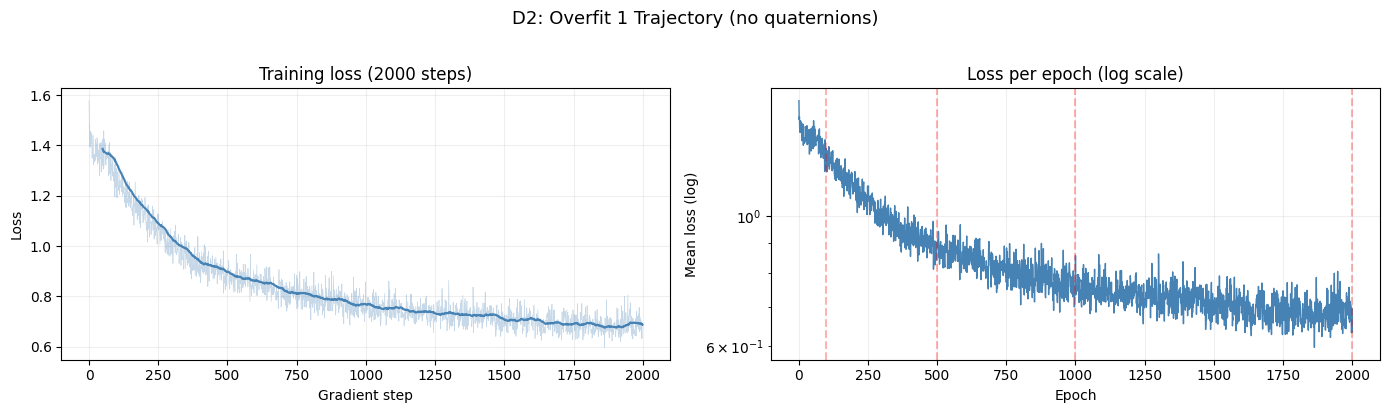


Loss progression:
  Epoch 1:    1.577846
  Epoch 100:  1.197580
  Epoch 500:  0.884298
  Epoch 1000: 0.856998
  Final:      0.634583

Loss is still high. Model may not be expressive enough or there's a bug.


In [7]:
# --- Loss curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(all_losses, alpha=0.3, color="steelblue", linewidth=0.5)
window = min(50, max(1, len(all_losses) // 20))
if window > 1:
    smoothed = np.convolve(all_losses, np.ones(window) / window, mode="valid")
    ax.plot(range(window - 1, len(all_losses)), smoothed, color="steelblue", linewidth=1.5)
ax.set_xlabel("Gradient step")
ax.set_ylabel("Loss")
ax.set_title(f"Training loss ({len(all_losses)} steps)")
ax.grid(alpha=0.2)

ax = axes[1]
ax.semilogy(range(1, EPOCHS + 1), epoch_mean_losses, color="steelblue", linewidth=1.0)
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean loss (log)")
ax.set_title("Loss per epoch (log scale)")
ax.grid(alpha=0.2)
for ep in CHECKPOINT_EPOCHS:
    if ep <= len(epoch_mean_losses):
        ax.axvline(ep, color="red", alpha=0.3, linestyle="--")

fig.suptitle("D2: Overfit 1 Trajectory (no quaternions)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nLoss progression:")
print(f"  Epoch 1:    {epoch_mean_losses[0]:.6f}")
print(f"  Epoch 100:  {epoch_mean_losses[min(99, len(epoch_mean_losses)-1)]:.6f}")
print(f"  Epoch 500:  {epoch_mean_losses[min(499, len(epoch_mean_losses)-1)]:.6f}")
print(f"  Epoch 1000: {epoch_mean_losses[min(999, len(epoch_mean_losses)-1)]:.6f}")
print(f"  Final:      {epoch_mean_losses[-1]:.6f}")

if epoch_mean_losses[-1] < 0.01:
    print("\nLoss is very low — model likely memorized the data. Good sign!")
elif epoch_mean_losses[-1] < 0.1:
    print("\nLoss is moderately low. Partial memorization.")
else:
    print("\nLoss is still high. Model may not be expressive enough or there's a bug.")

## Chunk Quality at Each Checkpoint

**Target:** L2 → 0 (perfect memorization of ~26 chunks).

We evaluate on the TRAINING data itself — this is intentional.
We want to know if the model CAN memorize, not if it generalizes.

In [8]:
from src.latent_sope.eval.metrics import l2_chunk_error

test_batch = next(iter(dataloader))
test_batch_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in test_batch.items()}

cat_sf = torch.cat([test_batch_dev["states_from"], test_batch_dev["actions_from"]], dim=-1)
cat_st = torch.cat([test_batch_dev["states_to"][:, :-1, :], test_batch_dev["actions_to"]], dim=-1)
x_gt = torch.cat([cat_sf, cat_st], dim=1)
cond = diffuser.make_cond(test_batch_dev)

state_dim = diffuser.state_dim
chunk_results = {}

print(f"Evaluating chunk reconstruction on {x_gt.shape[0]} training chunks...\n")

for ckpt_epoch in CHECKPOINT_EPOCHS:
    ckpt_file = ckpt_dir / f"sope_diffuser_epoch_{ckpt_epoch:04d}.pt"
    if not ckpt_file.exists():
        print(f"Checkpoint epoch {ckpt_epoch} not found, skipping.")
        continue

    payload = torch.load(str(ckpt_file), map_location=device, weights_only=False)
    diffuser.diffusion.load_state_dict(payload["diffusion_state_dict"])
    diffuser.diffusion.eval()

    with torch.no_grad():
        sample = diffuser.diffusion.conditional_sample(
            shape=x_gt.shape, cond=cond, guided=False, verbose=False,
        )
    x_hat = sample.trajectories

    x_gt_unnorm = diffuser.unnormalizer(x_gt).cpu().numpy()
    x_hat_unnorm = diffuser.unnormalizer(x_hat).cpu().numpy()

    err_s = l2_chunk_error(x_hat_unnorm[:, :, :state_dim], x_gt_unnorm[:, :, :state_dim])
    err_a = l2_chunk_error(x_hat_unnorm[:, :, state_dim:], x_gt_unnorm[:, :, state_dim:])

    chunk_results[ckpt_epoch] = {
        "state_l2": err_s.mean_l2,
        "state_l2_std": err_s.std_l2,
        "action_l2": err_a.mean_l2,
        "action_l2_std": err_a.std_l2,
        "rmse_per_dim": err_s.rmse_per_dim,
    }
    print(f"Epoch {ckpt_epoch:5d}: state L2 = {err_s.mean_l2:.4f} ± {err_s.std_l2:.4f}, "
          f"action L2 = {err_a.mean_l2:.4f} ± {err_a.std_l2:.4f}")

# Reload final
best_epoch = CHECKPOINT_EPOCHS[-1]
payload = torch.load(str(ckpt_dir / f"sope_diffuser_epoch_{best_epoch:04d}.pt"), map_location=device, weights_only=False)
diffuser.diffusion.load_state_dict(payload["diffusion_state_dict"])
diffuser.diffusion.eval()
print(f"\nLoaded epoch {best_epoch}.")

Evaluating chunk reconstruction on 17 training chunks...


                                                                                                    
1 / 256 [                                                            ]   0% | 15.4 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 28.4 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 39.6 Hz
t : 253
                                                                                                    
                                                     

                                                                                                    
                                                                                                    
6 / 256 [#                                                           ]   2% | 65.2 Hz
t : 250
                                                                                                    
                                                                                                    
7 / 256 [#                                                           ]   2% | 71.9 Hz
t : 249
                                                                                                    
                                                                                                    
8 / 256 [#                                                           ]   3% | 78.2 Hz
t : 248
                                                                                                    
           

                                                                                                    
                                                                                                    
24 / 256 [#####                                                       ]   9% | 131.5 Hz
t : 232
                                                                                                    
                                                                                                    
25 / 256 [#####                                                       ]   9% | 133.0 Hz
t : 231
                                                                                                    
                                                                                                    
26 / 256 [######                                                      ]  10% | 134.8 Hz
t : 230
                                                                                                    
     

                                                                                                    
                                                                                                    
47 / 256 [###########                                                 ]  18% | 158.6 Hz
t : 209
                                                                                                    
                                                                                                    
48 / 256 [###########                                                 ]  18% | 159.3 Hz
t : 208
                                                                                                    
                                                                                                    
49 / 256 [###########                                                 ]  19% | 160.1 Hz
t : 207
                                                                                                    
     

                                                                                                    
                                                                                                    
66 / 256 [###############                                             ]  25% | 170.1 Hz
t : 190
                                                                                                    
                                                                                                    
67 / 256 [###############                                             ]  26% | 170.4 Hz
t : 189
                                                                                                    
                                                                                                    
68 / 256 [###############                                             ]  26% | 171.0 Hz
t : 188
                                                                                                    
     

...

                                                                                                    
                                                                                                    
160 / 256 [#####################################                       ]  62% | 207.2 Hz
t : 96
                                                                                                    
                                                                                                    
161 / 256 [#####################################                       ]  62% | 207.1 Hz
t : 95
                                                                                                    
                                                                                                    
162 / 256 [#####################################                       ]  63% | 207.2 Hz
t : 94
                                                                                                    
     

                                                                                                    
                                                                                                    
177 / 256 [#########################################                   ]  69% | 206.8 Hz
t : 79
                                                                                                    
                                                                                                    
178 / 256 [#########################################                   ]  69% | 206.7 Hz
t : 78
                                                                                                    
                                                                                                    
179 / 256 [#########################################                   ]  69% | 206.8 Hz
t : 77
                                                                                                    
     

                                                                                                    
                                                                                                    
202 / 256 [###############################################             ]  78% | 185.0 Hz
t : 54
                                                                                                    
                                                                                                    
203 / 256 [###############################################             ]  79% | 189.0 Hz
t : 53
                                                                                                    
                                                                                                    
204 / 256 [###############################################             ]  79% | 192.9 Hz
t : 52
                                                                                                    
     

                                                                                                    
                                                                                                    
219 / 256 [###################################################         ]  85% | 199.9 Hz
t : 37
                                                                                                    
                                                                                                    
220 / 256 [###################################################         ]  85% | 199.9 Hz
t : 36
                                                                                                    
                                                                                                    
221 / 256 [###################################################         ]  86% | 200.5 Hz
t : 35
                                                                                                    
     

                                                                                                    
                                                                                                    
244 / 256 [#########################################################   ]  95% | 206.4 Hz
t : 12
                                                                                                    
                                                                                                    
245 / 256 [#########################################################   ]  95% | 206.3 Hz
t : 11
                                                                                                    
                                                                                                    
246 / 256 [#########################################################   ]  96% | 206.5 Hz
t : 10
                                                                                                    
     

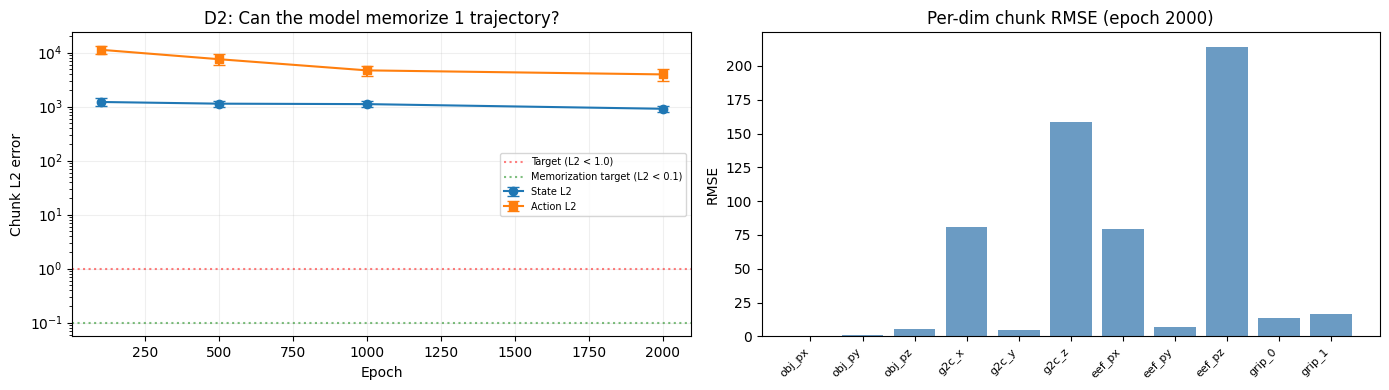


Final chunk L2: 910.7151
FAIL: Cannot memorize even 1 trajectory.
  -> Bug in model, loss, or conditioning. Debug needed.


In [9]:
# --- Chunk quality progression ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_list = sorted(chunk_results.keys())
state_l2s = [chunk_results[e]["state_l2"] for e in epochs_list]
action_l2s = [chunk_results[e]["action_l2"] for e in epochs_list]
state_stds = [chunk_results[e]["state_l2_std"] for e in epochs_list]
action_stds = [chunk_results[e]["action_l2_std"] for e in epochs_list]

ax = axes[0]
ax.errorbar(epochs_list, state_l2s, yerr=state_stds, marker="o", label="State L2", capsize=4)
ax.errorbar(epochs_list, action_l2s, yerr=action_stds, marker="s", label="Action L2", capsize=4)
ax.axhline(1.0, color="red", linestyle=":", alpha=0.5, label="Target (L2 < 1.0)")
ax.axhline(0.1, color="green", linestyle=":", alpha=0.5, label="Memorization target (L2 < 0.1)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Chunk L2 error")
ax.set_title("D2: Can the model memorize 1 trajectory?")
ax.legend(fontsize=7)
ax.set_yscale("log")
ax.grid(alpha=0.2)

# Per-dim RMSE at final checkpoint
ax = axes[1]
final_rmse = chunk_results[epochs_list[-1]]["rmse_per_dim"]
ax.bar(range(len(final_rmse)), final_rmse, color="steelblue", alpha=0.8)
ax.set_xticks(range(len(DIM_LABELS)))
ax.set_xticklabels(DIM_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("RMSE")
ax.set_title(f"Per-dim chunk RMSE (epoch {epochs_list[-1]})")

plt.tight_layout()
plt.show()

final_l2 = chunk_results[epochs_list[-1]]["state_l2"]
print(f"\nFinal chunk L2: {final_l2:.4f}")
if final_l2 < 0.1:
    print("PASS: Model memorized the trajectory. The architecture works.")
    print("  -> Problem is generalization/data diversity, not model capacity.")
elif final_l2 < 1.0:
    print("PARTIAL: Good reconstruction but not perfect memorization.")
    print("  -> Model is learning but may need more epochs or higher LR.")
else:
    print("FAIL: Cannot memorize even 1 trajectory.")
    print("  -> Bug in model, loss, or conditioning. Debug needed.")

## Stitching on the Memorized Trajectory

Generate a synthetic trajectory starting from the same initial state as the real one.
If memorization worked, the stitched trajectory should closely match the real one.

In [10]:
MAX_LENGTH = HORIZON

# Use the real trajectory's initial state
traj = load_rollout_latents(rollout_paths[0])
latents = traj.latents
if latents.ndim == 3:
    latents = latents[:, 0, :]

init_state = torch.tensor(latents[0:1], dtype=torch.float32)  # (1, 11)
print(f"Initial state: {init_state.shape}")
print(f"Generating 1 stitched trajectory (max {MAX_LENGTH} steps)...\n")

syn_states, syn_actions, end_indices = diffuser.generate_full_trajectory(
    initial_states=init_state,
    max_length=MAX_LENGTH,
    guided=False,
    verbose=False,
)

print(f"Generated trajectory:")
print(f"  states shape: {syn_states.shape}")
print(f"  state range: [{syn_states.min():.4f}, {syn_states.max():.4f}]")
print(f"  action range: [{syn_actions.min():.4f}, {syn_actions.max():.4f}]")

# Real trajectory for comparison
real_T = latents.shape[0]
real_states = latents[:MAX_LENGTH][None, :, :]  # (1, T_real, 11)
real_actions = traj.actions[:MAX_LENGTH][None, :, :]  # (1, T_real, 7)

# Truncate both to the shorter length so shapes match
T_common = min(real_states.shape[1], syn_states.shape[1])
real_states = real_states[:, :T_common, :]
real_actions = real_actions[:, :T_common, :]
syn_states = syn_states[:, :T_common, :]
syn_actions = syn_actions[:, :T_common, :]
end_indices = np.minimum(end_indices, T_common)

print(f"\nReal trajectory:")
print(f"  original length: {real_T}, truncated to: {T_common}")
print(f"  state range: [{real_states.min():.4f}, {real_states.max():.4f}]")
print(f"  action range: [{real_actions.min():.4f}, {real_actions.max():.4f}]")

# Quick blowup check
blowup_ratio = max(abs(syn_states.min()), abs(syn_states.max())) / max(abs(real_states.min()), abs(real_states.max()), 1e-6)
print(f"\nBlowup ratio (syn max / real max): {blowup_ratio:.1f}x")
if blowup_ratio < 2.0:
    print("  -> Synthetic stays in distribution!")
elif blowup_ratio < 10.0:
    print("  -> Moderate blowup. Stitching drift is present but contained.")
else:
    print(f"  -> Significant blowup ({blowup_ratio:.0f}x). Stitching is amplifying errors.")

Initial state: torch.Size([1, 11])
Generating 1 stitched trajectory (max 60 steps)...


                                                                                                    
1 / 256 [                                                            ]   0% | 52.0 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 81.8 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 100.7 Hz
t : 253
                                                                                                    
                       

                                                                                                    
                                                                                                    
23 / 256 [#####                                                       ]   8% | 179.2 Hz
t : 233
                                                                                                    
                                                                                                    
24 / 256 [#####                                                       ]   9% | 179.8 Hz
t : 232
                                                                                                    
                                                                                                    
25 / 256 [#####                                                       ]   9% | 180.5 Hz
t : 231
                                                                                                    
     

                                                                                                    
                                                                                                    
39 / 256 [#########                                                   ]  15% | 188.6 Hz
t : 217
                                                                                                    
                                                                                                    
40 / 256 [#########                                                   ]  15% | 188.8 Hz
t : 216
                                                                                                    
                                                                                                    
41 / 256 [#########                                                   ]  16% | 189.1 Hz
t : 215
                                                                                                    
     

                                                                                                    
                                                                                                    
64 / 256 [###############                                             ]  25% | 193.5 Hz
t : 192
                                                                                                    
                                                                                                    
65 / 256 [###############                                             ]  25% | 193.5 Hz
t : 191
                                                                                                    
                                                                                                    
66 / 256 [###############                                             ]  25% | 193.7 Hz
t : 190
                                                                                                    
     

                                                                                                    
                                                                                                    
81 / 256 [##################                                          ]  31% | 195.8 Hz
t : 175
                                                                                                    
                                                                                                    
82 / 256 [###################                                         ]  32% | 195.9 Hz
t : 174
                                                                                                    
                                                                                                    
83 / 256 [###################                                         ]  32% | 196.1 Hz
t : 173
                                                                                                    
     

...

                                                                                                    
                                                                                                    
160 / 256 [#####################################                       ]  62% | 209.5 Hz
t : 96
                                                                                                    
                                                                                                    
161 / 256 [#####################################                       ]  62% | 209.1 Hz
t : 95
                                                                                                    
                                                                                                    
162 / 256 [#####################################                       ]  63% | 209.1 Hz
t : 94
                                                                                                    
     

                                                                                                    
                                                                                                    
178 / 256 [#########################################                   ]  69% | 209.2 Hz
t : 78
                                                                                                    
                                                                                                    
179 / 256 [#########################################                   ]  69% | 209.1 Hz
t : 77
                                                                                                    
                                                                                                    
180 / 256 [##########################################                  ]  70% | 209.1 Hz
t : 76
                                                                                                    
     

                                                                                                    
                                                                                                    
203 / 256 [###############################################             ]  79% | 196.0 Hz
t : 53
                                                                                                    
                                                                                                    
204 / 256 [###############################################             ]  79% | 196.6 Hz
t : 52
                                                                                                    
                                                                                                    
205 / 256 [################################################            ]  80% | 197.8 Hz
t : 51
                                                                                                    
     

                                                                                                    
                                                                                                    
221 / 256 [###################################################         ]  86% | 204.9 Hz
t : 35
                                                                                                    
                                                                                                    
222 / 256 [####################################################        ]  86% | 204.4 Hz
t : 34
                                                                                                    
                                                                                                    
223 / 256 [####################################################        ]  87% | 204.3 Hz
t : 33
                                                                                                    
     

                                                                                                    
                                                                                                    
245 / 256 [#########################################################   ]  95% | 206.2 Hz
t : 11
                                                                                                    
                                                                                                    
246 / 256 [#########################################################   ]  96% | 206.0 Hz
t : 10
                                                                                                    
                                                                                                    
247 / 256 [#########################################################   ]  96% | 206.2 Hz
t : 9
                                                                                                    
      

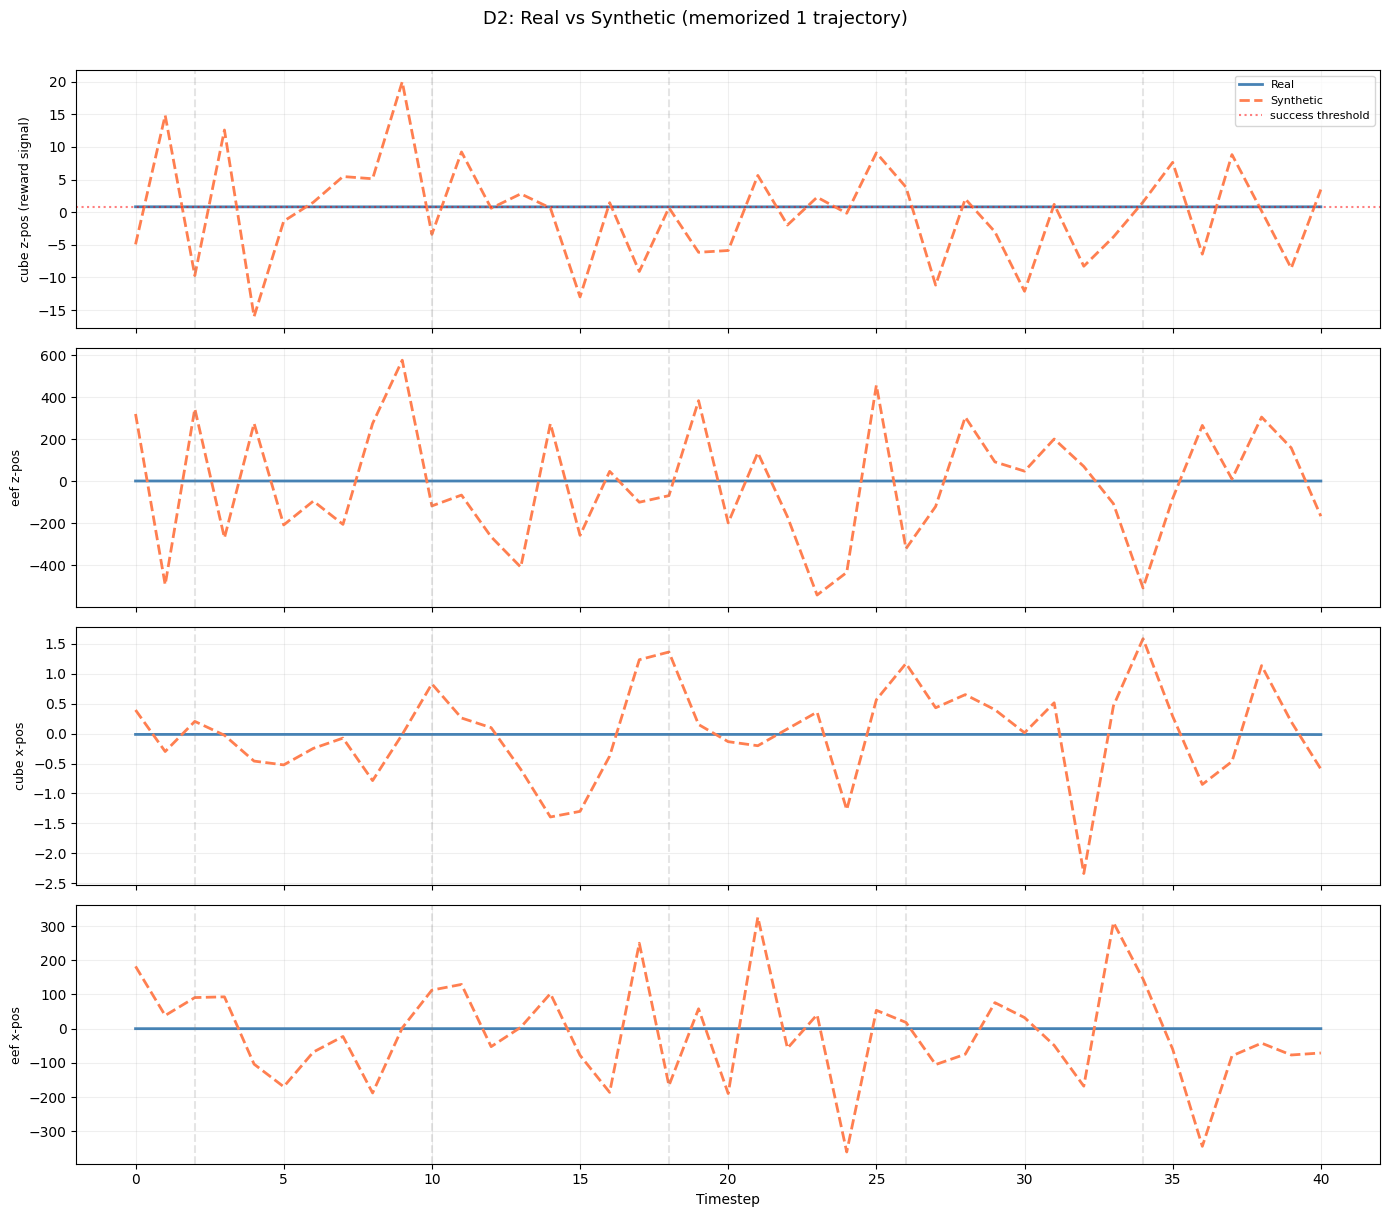

In [11]:
# --- Visual: real vs synthetic trajectory (all dims) ---
key_dims = [
    (CUBE_Z_IDX, "cube z-pos (reward signal)"),
    (EEF_Z_IDX, "eef z-pos"),
    (CUBE_X_IDX, "cube x-pos"),
    (EEF_X_IDX, "eef x-pos"),
]

fig, axes = plt.subplots(len(key_dims), 1, figsize=(14, 3 * len(key_dims)), sharex=True)
for row, (dim_idx, dim_name) in enumerate(key_dims):
    ax = axes[row]
    ax.plot(real_states[0, :, dim_idx], color="steelblue", linewidth=2, label="Real")
    ax.plot(syn_states[0, :, dim_idx], color="coral", linewidth=2, linestyle="--", label="Synthetic")
    ax.set_ylabel(dim_name, fontsize=9)
    if dim_idx == CUBE_Z_IDX:
        ax.axhline(SUCCESS_THRESHOLD, color="red", linestyle=":", alpha=0.5, label="success threshold")
    # Mark chunk boundaries
    chunk_size = diffusion_config.chunk_horizon
    frame_stack = diffusion_config.frame_stack
    for boundary in range(frame_stack, T_common, chunk_size):
        ax.axvline(boundary, color="gray", alpha=0.2, linestyle="--")
    ax.grid(alpha=0.2)
    if row == 0:
        ax.legend(fontsize=8)

axes[-1].set_xlabel("Timestep")
fig.suptitle("D2: Real vs Synthetic (memorized 1 trajectory)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

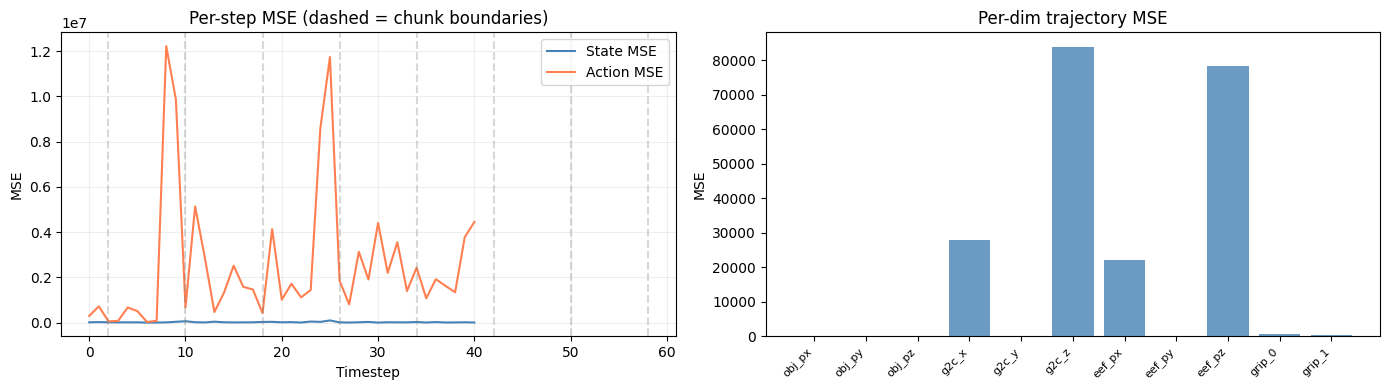

Trajectory State MSE:  19422.731707
Trajectory Action MSE: 2600417.226481

Dim         Real mean   Syn mean   Real std    Syn std       Real [min,max]        Syn [min,max]
------------------------------------------------------------------------------------------------------
obj_px        -0.0136     0.0109     0.0004     0.7840 [ -0.016,  -0.013]  [ -2.338,   1.586]
obj_py         0.0005     0.2189     0.0008     1.5963 [  0.000,   0.004]  [ -2.728,   4.441]
obj_pz         0.8214    -0.1022     0.0026     7.6813 [  0.819,   0.831]  [-15.998,  19.998]
g2c_x          0.0160   -32.8256     0.0352   163.9927 [ -0.013,   0.089]  [-413.529, 352.331]
g2c_y         -0.0074     5.0971     0.0033     9.5686 [ -0.011,   0.003]  [-14.460,  26.818]
g2c_z         -0.0910   -91.0582     0.0615   274.9142 [ -0.188,  -0.007]  [-824.842, 338.965]
eef_px        -0.0296   -15.8909     0.0352   147.4824 [ -0.103,  -0.000]  [-360.703, 326.010]
eef_py         0.0079    -1.0500     0.0026     8.5093 [ -0.000,

In [12]:
# --- Per-step MSE ---
from src.latent_sope.eval.metrics import trajectory_reconstruction_mse

recon = trajectory_reconstruction_mse(
    real_states.astype(np.float32), syn_states,
    real_actions.astype(np.float32), syn_actions,
    end_indices,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(recon.state_mse_per_step, color="steelblue", linewidth=1.5, label="State MSE")
ax.plot(recon.action_mse_per_step, color="coral", linewidth=1.5, label="Action MSE")
for boundary in range(frame_stack, MAX_LENGTH, chunk_size):
    ax.axvline(boundary, color="gray", alpha=0.3, linestyle="--")
ax.set_xlabel("Timestep")
ax.set_ylabel("MSE")
ax.set_title("Per-step MSE (dashed = chunk boundaries)")
ax.legend()
ax.grid(alpha=0.2)

ax = axes[1]
ax.bar(range(len(recon.state_mse_per_dim)), recon.state_mse_per_dim, color="steelblue", alpha=0.8)
ax.set_xticks(range(len(DIM_LABELS)))
ax.set_xticklabels(DIM_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("MSE")
ax.set_title("Per-dim trajectory MSE")

plt.tight_layout()
plt.show()

print(f"Trajectory State MSE:  {recon.state_mse:.6f}")
print(f"Trajectory Action MSE: {recon.action_mse:.6f}")

# Marginal statistics
print(f"\n{'Dim':<10} {'Real mean':>10} {'Syn mean':>10} {'Real std':>10} {'Syn std':>10} {'Real [min,max]':>20} {'Syn [min,max]':>20}")
print("-" * 102)
for d, label in enumerate(DIM_LABELS):
    r, s = real_states[0, :, d], syn_states[0, :, d]
    print(f"{label:<10} {r.mean():10.4f} {s.mean():10.4f} {r.std():10.4f} {s.std():10.4f} "
          f"[{r.min():7.3f}, {r.max():7.3f}]  [{s.min():7.3f}, {s.max():7.3f}]")

## OPE on Memorized Trajectory

In [13]:
from src.latent_sope.eval.metrics import ope_eval

# Compute returns directly from cube z
syn_cube_z = syn_states[:, :, CUBE_Z_IDX]
syn_rewards = (syn_cube_z > SUCCESS_THRESHOLD).astype(np.float32)
syn_returns = syn_rewards.sum(axis=1)

real_cube_z = real_states[:, :, CUBE_Z_IDX]
real_rewards_traj = (real_cube_z > SUCCESS_THRESHOLD).astype(np.float32)
real_returns = real_rewards_traj.sum(axis=1)

ope_result = ope_eval(oracle_value, syn_returns)

final_l2 = chunk_results[sorted(chunk_results.keys())[-1]]["state_l2"]

print("=" * 60)
print("D2: Overfit 1 Trajectory — Summary")
print("=" * 60)
print(f"  Oracle V^pi:          {oracle_value:.3f}")
print(f"  Real traj return:     {real_returns[0]:.1f}")
print(f"  Synthetic return:     {syn_returns[0]:.1f}")
print(f"  OPE estimate:         {ope_result.ope_estimate:.3f}")
print(f"  Relative error:       {ope_result.relative_error:.2%}")
print(f"  Final chunk L2:       {final_l2:.4f}")
print(f"  State MSE:            {recon.state_mse:.4f}")
print(f"  Blowup ratio:         {blowup_ratio:.1f}x")
print("=" * 60)

print(f"\n--- Verdict ---")
if final_l2 < 0.1 and blowup_ratio < 2.0:
    print("PASS: Model memorized chunks AND stitching works.")
    print("  -> Architecture is correct. Problem is data diversity.")
    print("  -> Next: Scale to 50+ rollouts with this config.")
elif final_l2 < 0.1 and blowup_ratio >= 2.0:
    print("PARTIAL PASS: Chunks memorized but stitching drifts.")
    print("  -> Chunk generation works. Stitching needs fixes (overlap, clamping).")
elif final_l2 < 1.0:
    print("PARTIAL: Good chunks but not perfect memorization.")
    print("  -> Model is learning. May need more epochs or LR tuning.")
else:
    print("FAIL: Cannot memorize 1 trajectory.")
    print("  -> Debug: check loss function, conditioning, model architecture.")

D2: Overfit 1 Trajectory — Summary
  Oracle V^pi:          0.540
  Real traj return:     0.0
  Synthetic return:     19.0
  OPE estimate:         19.000
  Relative error:       3418.52%
  Final chunk L2:       910.7151
  State MSE:            19422.7317
  Blowup ratio:         816.1x

--- Verdict ---
FAIL: Cannot memorize 1 trajectory.
  -> Debug: check loss function, conditioning, model architecture.


## Conclusions

Fill in after running:

**Can the model memorize 1 trajectory?**
- Final loss: ?
- Chunk L2: ? (target < 0.1)
- Trajectory MSE: ?
- Blowup ratio: ?

**If PASS:**
The model architecture, loss function, and conditioning all work.
The 8.5k/500k failures are due to insufficient data diversity or undertrained model,
not architectural bugs. Next step: run D1 (no-quat) at scale (50 rollouts, 500k steps).

**If FAIL:**
Something fundamental is broken. Check:
1. Is `make_cond()` pinning the right states at the right timesteps?
2. Is the loss actually backpropagating through the UNet?
3. Is the noise schedule reasonable? (try fewer diffusion steps)
4. Visualize what the model predicts vs ground truth at individual timesteps.